The Expected MGC of The User Exceeds The Maximum Allowable MGC
Which Means User Violated The Max MGC Rule
So the First Image Of The Plot Area and Maximum Ground Coverage,
The Second Image of Max Allowable Height Is Generated Using The Max MGC




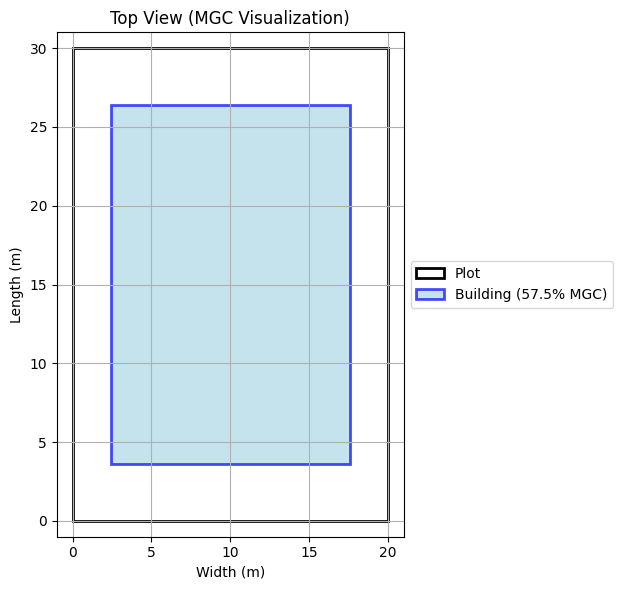



----------------------------------------


The Max Allowable Height Of The Building Is Shown Through A Image Below




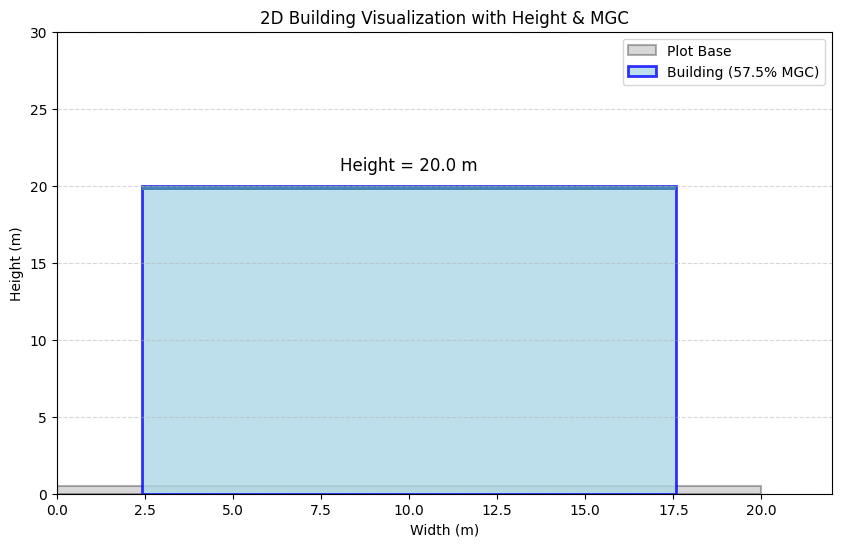



----------------------------------------



========== LAND USE & BUILDING COMPLIANCE REPORT ==========

1. APPLICANT INFORMATION
Name of Applicant        : Ahnab Intesar
City Corporation        : North
Ward Number             : Ward-16

2. PLOT & LAND INFORMATION
Land Use Type           : Commercial
Plot Length             : 30.0
Plot Width             : 20.0
Plot Area               : 600.0
Ground Floor Area       : 450.0
Adjacent Road Width     : 15.0

3. CALCULATED PARAMETERS
User MGC                : 75.00
Maximum Allowable MGC   : 57.5
Area FAR (Ward ভিত্তিক) : 2.1
Plot FAR               : 3.5

4. COMPLIANCE CHECK
MGC Compliance Status   : VIOLATED

5. BUILDING DEVELOPMENT DETAILS
Applicant Name          : Ahnab Intesar
Ward Number             : Ward-16
Land Use                : Commercial
Plot Area               : 600.0
User MGC                : 75.00
Allowed MGC             : 57.5
Compliance Status       : VIOLATED
Max Allowable Height    : 20.0 meters



In [ ]:



import streamlit as st

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Permit.py", layout='wide')
st.title('Building Regulation & Height Calculator')

s_areafar=pd.read_csv('dscc_ward_far.csv')
n_areafar=pd.read_csv('dncc_ward_far.csv')
mgc_residential=pd.read_csv('mgc_regulations_residential.csv')
mgc_commercial=pd.read_csv('mgc_regulations_institute.csv')
far_commercial=pd.read_csv('far_regulatioons_institute.csv')
far_residential=pd.read_csv('far_regulations_dap.csv')

st.sidebar.header('User Input')

user_name=st.sidebar.text_input('Enter your full name')


city_corp=st.sidebar.selectbox('Is your dhaka city corporation North or South',['North','South'])

  

ward_input=st.sidebar.number_input('Enter your Ward number',step=1)
ward=f'Ward-{int(ward_input):02d}'

   

land_use_groups={
    'Residential':'residential',
    'Commercial':'non-residential',
    'Institutional':'non-residential',
    'Mixed Use':'non-residential',
    'Open Space':'non-residential',
    'Industrial':'non-residential'
}


land_use=st.sidebar.selectbox('Enter your land use',list(land_use_groups.keys()))




plot_length=st.sidebar.number_input('Enter your plot length',min_value=0.0)
plot_width=st.sidebar.number_input('Enter your plot width', min_value=0.0)
g_floor_area=st.sidebar.number_input('Enter your ground floor area',min_value=0.0)
adj_road_width=st.sidebar.number_input('Enter your adjacent road width',min_value=0.0)
if st.sidebar.button('Calculate'):
  plot_area=plot_length*plot_width

  if plot_area<=0:
    st.error('Invalid Plot Size')
    st.stop()


  if land_use_groups.get(land_use)=='residential':

      matched_row1=mgc_residential[(mgc_residential['Min Land Size ']<=plot_area)&(mgc_residential['Max Land Size ']>=plot_area)]

  elif land_use_groups.get(land_use)=='non-residential':
      matched_row1=mgc_commercial[(mgc_commercial['Min Land Size ']<=plot_area)&(mgc_commercial['Max Land Size ']>=plot_area)]

  if  matched_row1.empty:
      st.error('Invalid Plot Size, No MGC found')
      st.stop()
  max_mgc=matched_row1['MGC'].values[0]
     









    
  if land_use_groups.get(land_use)=='residential':
      
      matched_row=far_residential[(far_residential['Min  Road Width']<=adj_road_width)&(far_residential['Max Road Width']>=adj_road_width)]
      
      if matched_row.empty:
        st.error('Inavlid Road Width, No FAR found')
        st.stop()

      plot_far=matched_row['Area FAR Value'].values[0]
      
  elif land_use_groups.get(land_use)=='non-residential':
      

      matched_row=far_commercial[(far_commercial['Min Land Size ']<=plot_area)&(far_commercial['Max Land Size ']>=plot_area)]
      if  matched_row.empty:
        st.error('Inavlid Plot Size, No FAR found')
        st.stop()


      plot_far=matched_row['FAR'].values[0]
       









if city_corp=='North':
  exists=ward in n_areafar['Ward'].values
  if not exists:
     st.error('Ward Number Not Found')
     st.stop()

  row=n_areafar.loc[n_areafar['Ward']==ward]
  

elif city_corp=="South":
  exists=ward in s_areafar['Ward'].values
  if not exists:
     st.error('Ward Number Not Found')
     st.stop()
  row=s_areafar.loc[s_areafar['Ward']==ward]

area_far=row['Area FAR'].values[0]

user_mgc = round((g_floor_area / plot_area) * 100, 2)
g_floor_area2=(plot_area*max_mgc)/100

def calculate_ressidential_height(user_mgc,max_mgc,plot_far,area_far,plot_area):
  plot_size=plot_area/66.89

  mgc_used=user_mgc if user_mgc<=max_mgc else max_mgc
  base_far=plot_far if plot_far<area_far else area_far
  total_floorarea=base_far*plot_size*720
  allowable_ground_coverage=(user_mgc/100)*plot_size*720
  height = round(total_floorarea / allowable_ground_coverage, 0)

  return height,mgc_used




def calculate_other_height(plot_far,area_far,plot_area,g_floor_area):
  FAR=plot_far if plot_far>area_far else area_far

  if user_mgc<=max_mgc:
    ground_floor_area=g_floor_area
  else:
    ground_floor_area=g_floor_area2

  allowable_building_floors=(FAR*plot_area)/ground_floor_area
  height = round(allowable_building_floors * 3.25, 0)
  return height



if land_use_groups.get(land_use)=='residential':
  allowable_building_height,mgc_percent=calculate_ressidential_height(user_mgc,max_mgc,plot_far,area_far,plot_area)

elif land_use_groups.get(land_use)=='non-residential':
  allowable_building_height=calculate_other_height(plot_far,area_far,plot_area,g_floor_area)
  mgc_percent=user_mgc if user_mgc<=max_mgc else max_mgc



if user_mgc<=max_mgc:
  st.success('MGC NOT VIOLATED')
else:
  st.warning('MGC VIOLATED - USING MAX MGC')

col1,col2=st.columns(2)

with col1:

  st.subheader('Graphs')
  import matplotlib.pyplot as plt
  import matplotlib.patches as patches
  import math

  scale = math.sqrt(mgc_percent / 100)

  building_width = plot_width * scale
  building_length = plot_length * scale

  x_offset = (plot_width - building_width) / 2
  y_offset = (plot_length - building_length) / 2

  fig, ax = plt.subplots(figsize=(8, 6))

  plot_rect = patches.Rectangle(
  (0, 0),
  plot_width,
  plot_length,
  linewidth=2,
  edgecolor='black',
  facecolor='none',
  label='Plot'
  )
  ax.add_patch(plot_rect)

  building_rect = patches.Rectangle(
  (x_offset, y_offset),
  building_width,
  building_length,
  linewidth=2,
  edgecolor='blue',
  facecolor='lightblue',
  alpha=0.7,
  label=f'Building ({mgc_percent}% MGC)'
  )
  ax.add_patch(building_rect)

  ax.set_xlim(-1, plot_width + 1)
  ax.set_ylim(-1, plot_length + 1)
  ax.set_aspect('equal')

  ax.set_title("Top View (MGC Visualization)")
  ax.set_xlabel("Width (m)")
  ax.set_ylabel("Length (m)")

  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

  plt.tight_layout()

  plt.grid(True)
  st.pyplot(fig)


  building_height = allowable_building_height

  buildable_area = plot_area * (mgc_percent / 100)

  plot_ratio = plot_width / plot_length
  building_length = (buildable_area / plot_ratio)**0.5
  building_width = building_length * plot_ratio

  x_offset = (plot_width - building_width)/2
  y_offset = (plot_length - building_length)/2

  fig, ax = plt.subplots(figsize=(10,6))

  plot_rect = patches.Rectangle(
      (0,0),
      plot_width,
      0.5,
      linewidth=1.5,
      edgecolor='black',
      facecolor='grey',
      alpha=0.3,
      label='Plot Base'
  )
  ax.add_patch(plot_rect)

  building_rect = patches.Rectangle(
      (x_offset, 0),
      building_width,
      building_height,
      linewidth=2,
      edgecolor='blue',
      facecolor='lightblue',
      alpha=0.8,
      label=f'Building ({mgc_percent}% MGC)'
  )
  ax.add_patch(building_rect)

  roof = patches.Rectangle(
      (x_offset, building_height - 0.3),
      building_width,
      0.3,
      facecolor='steelblue'
  )
  ax.add_patch(roof)

  ax.text(
      x_offset + building_width/2,
      building_height + 1,
      f"Height = {building_height} m",
      ha='center',
      fontsize=12
  )

  ax.set_xlim(0, plot_width + 2)
  ax.set_ylim(0, building_height + 10)
  ax.set_xlabel("Width (m)")
  ax.set_ylabel("Height (m)")
  ax.set_title("2D Building Visualization with Height & MGC")
  ax.set_aspect('auto')
  plt.legend()
  plt.grid(True, axis='y', linestyle='--', alpha=0.5)
  st.pyplot(fig)

 

    


with col2:
    
    
    st.subheader("📄 Land Use & Building Compliance Report")

   
    st.markdown("### 1. Applicant Information")
    st.markdown(f"- **Name of Applicant:** {user_name}")
    st.markdown(f"- **City Corporation:** {city_corp}")
    st.markdown(f"- **Ward Number:** {ward}")

    st.markdown("---") 

   
    st.markdown("### 2. Plot & Land Information")
    st.markdown(f"- **Land Use Type:** {land_use}")
    st.markdown(f"- **Plot Length:** {plot_length} m")
    st.markdown(f"- **Plot Width:** {plot_width} m")
    st.markdown(f"- **Plot Area:** {plot_area} m²")
    st.markdown(f"- **Ground Floor Area:** {g_floor_area} m²")
    st.markdown(f"- **Adjacent Road Width:** {adj_road_width} m")

    st.markdown("---")

    
    st.markdown("### 3. Calculated Parameters")
    st.markdown(f"- **User MGC:** {user_mgc:.2f} %")
    st.markdown(f"- **Maximum Allowable MGC:** {max_mgc} %")
    st.markdown(f"- **Area FAR (Ward-based):** {area_far}")
    st.markdown(f"- **Plot FAR:** {plot_far}")

    st.markdown("---")

   
    st.markdown("### 4. Compliance Check")
    compliance_status = "NOT VIOLATED" if user_mgc <= max_mgc else "VIOLATED"
    if compliance_status == "NOT VIOLATED":
        st.success(f"- **MGC Compliance Status:** {compliance_status}")
    else:
        st.warning(f"- **MGC Compliance Status:** {compliance_status} (Max MGC applied)")

    st.markdown("---")

    
    st.markdown("### 5. Building Development Details")
    st.markdown(f"- **Maximum Allowable Height:** {allowable_building_height} m")
    st.markdown(f"- **Allowed Ground Coverage:** {mgc_percent} % of plot area")

    st.markdown("---")

    
    st.markdown("_This report is generated automatically By Permit.py._")
    st.markdown("_All values are based on the Dhaka City Corporation rules and user-provided plot data._")

In [1]:
import os
print(os.getcwd())

c:\Users\HP\OneDrive\Documents\Desktop\cse_project


In [4]:
%pip install streamlit numpy pandas matplotlib

^C
Note: you may need to restart the kernel to use updated packages.
